## Thu thập dữ liệu

In [19]:
# Data from https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
breast_cancer_wisconsin_original = fetch_ucirepo(id=15) 

# data (as pandas dataframes) 
data = breast_cancer_wisconsin_original.data.original

In [20]:
import mlflow
import mlflow.sklearn

# Thiết lập experiment
mlflow.set_experiment("Breast Cancer Diagnosis")

<Experiment: artifact_location='mlflow-artifacts:/669272814043531891', creation_time=1773216676515, experiment_id='669272814043531891', last_update_time=1773216676515, lifecycle_stage='active', name='Breast Cancer Diagnosis', tags={}, workspace='default'>

In [21]:
data

,Sample_code_number,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1.0,3,1,1,2
1,1002945,5,4,4,5,7,10.0,3,2,1,2
2,1015425,3,1,1,1,2,2.0,3,1,1,2
3,1016277,6,8,8,1,3,4.0,3,7,1,2
4,1017023,4,1,1,3,2,1.0,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...
694,776715,3,1,1,1,3,2.0,1,1,1,2
695,841769,2,1,1,1,2,1.0,1,1,1,2
696,888820,5,10,10,3,7,3.0,8,10,2,4
697,897471,4,8,6,4,3,4.0,10,6,1,4


## Chuẩn hóa nhãn đầu ra

In [22]:
data['Class'] = data['Class'].replace({2:0, 4:1}) 
# 0: benign (lành tính), 1: malignant (ác tính)

## Xử lý dữ liệu khuyết

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Sample_code_number           699 non-null    int64  
 1   Clump_thickness              699 non-null    int64  
 2   Uniformity_of_cell_size      699 non-null    int64  
 3   Uniformity_of_cell_shape     699 non-null    int64  
 4   Marginal_adhesion            699 non-null    int64  
 5   Single_epithelial_cell_size  699 non-null    int64  
 6   Bare_nuclei                  683 non-null    float64
 7   Bland_chromatin              699 non-null    int64  
 8   Normal_nucleoli              699 non-null    int64  
 9   Mitoses                      699 non-null    int64  
 10  Class                        699 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 60.2 KB


In [24]:
data.describe()

,Sample_code_number,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
count,6.990000e+02,699.000000,699.000000,699.000000,699.000000,699.000000,683.000000,699.000000,699.000000,699.000000,699.000000
mean,1.071704e+06,4.417740,3.134478,3.207439,2.806867,3.216023,3.544656,3.437768,2.866953,1.589413,0.344778
std,6.170957e+05,2.815741,3.051459,2.971913,2.855379,2.214300,3.643857,2.438364,3.053634,1.715078,0.475636
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,8.706885e+05,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,0.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,0.000000
75%,1.238298e+06,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,1.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,1.000000


In [25]:
data['Bare_nuclei'] = data.Bare_nuclei.fillna(data.Bare_nuclei.mean())

In [26]:
data.isnull().sum()

Sample_code_number             0
Clump_thickness                0
Uniformity_of_cell_size        0
Uniformity_of_cell_shape       0
Marginal_adhesion              0
Single_epithelial_cell_size    0
Bare_nuclei                    0
Bland_chromatin                0
Normal_nucleoli                0
Mitoses                        0
Class                          0
dtype: int64

## Kiểm tra dữ liệu trùng lặp

In [27]:
# Check duplicate
data.duplicated().sum()

np.int64(8)

In [28]:
data = data.drop_duplicates()
# Bỏ cột ID
if "Sample_code_number" in data.columns:
    data = data.drop(columns=["Sample_code_number"])
print(data.shape)

(691, 10)


## Trực quan hóa dữ liệu

/tmp/ipykernel_124/2106171476.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['Benign', 'Malignant'])


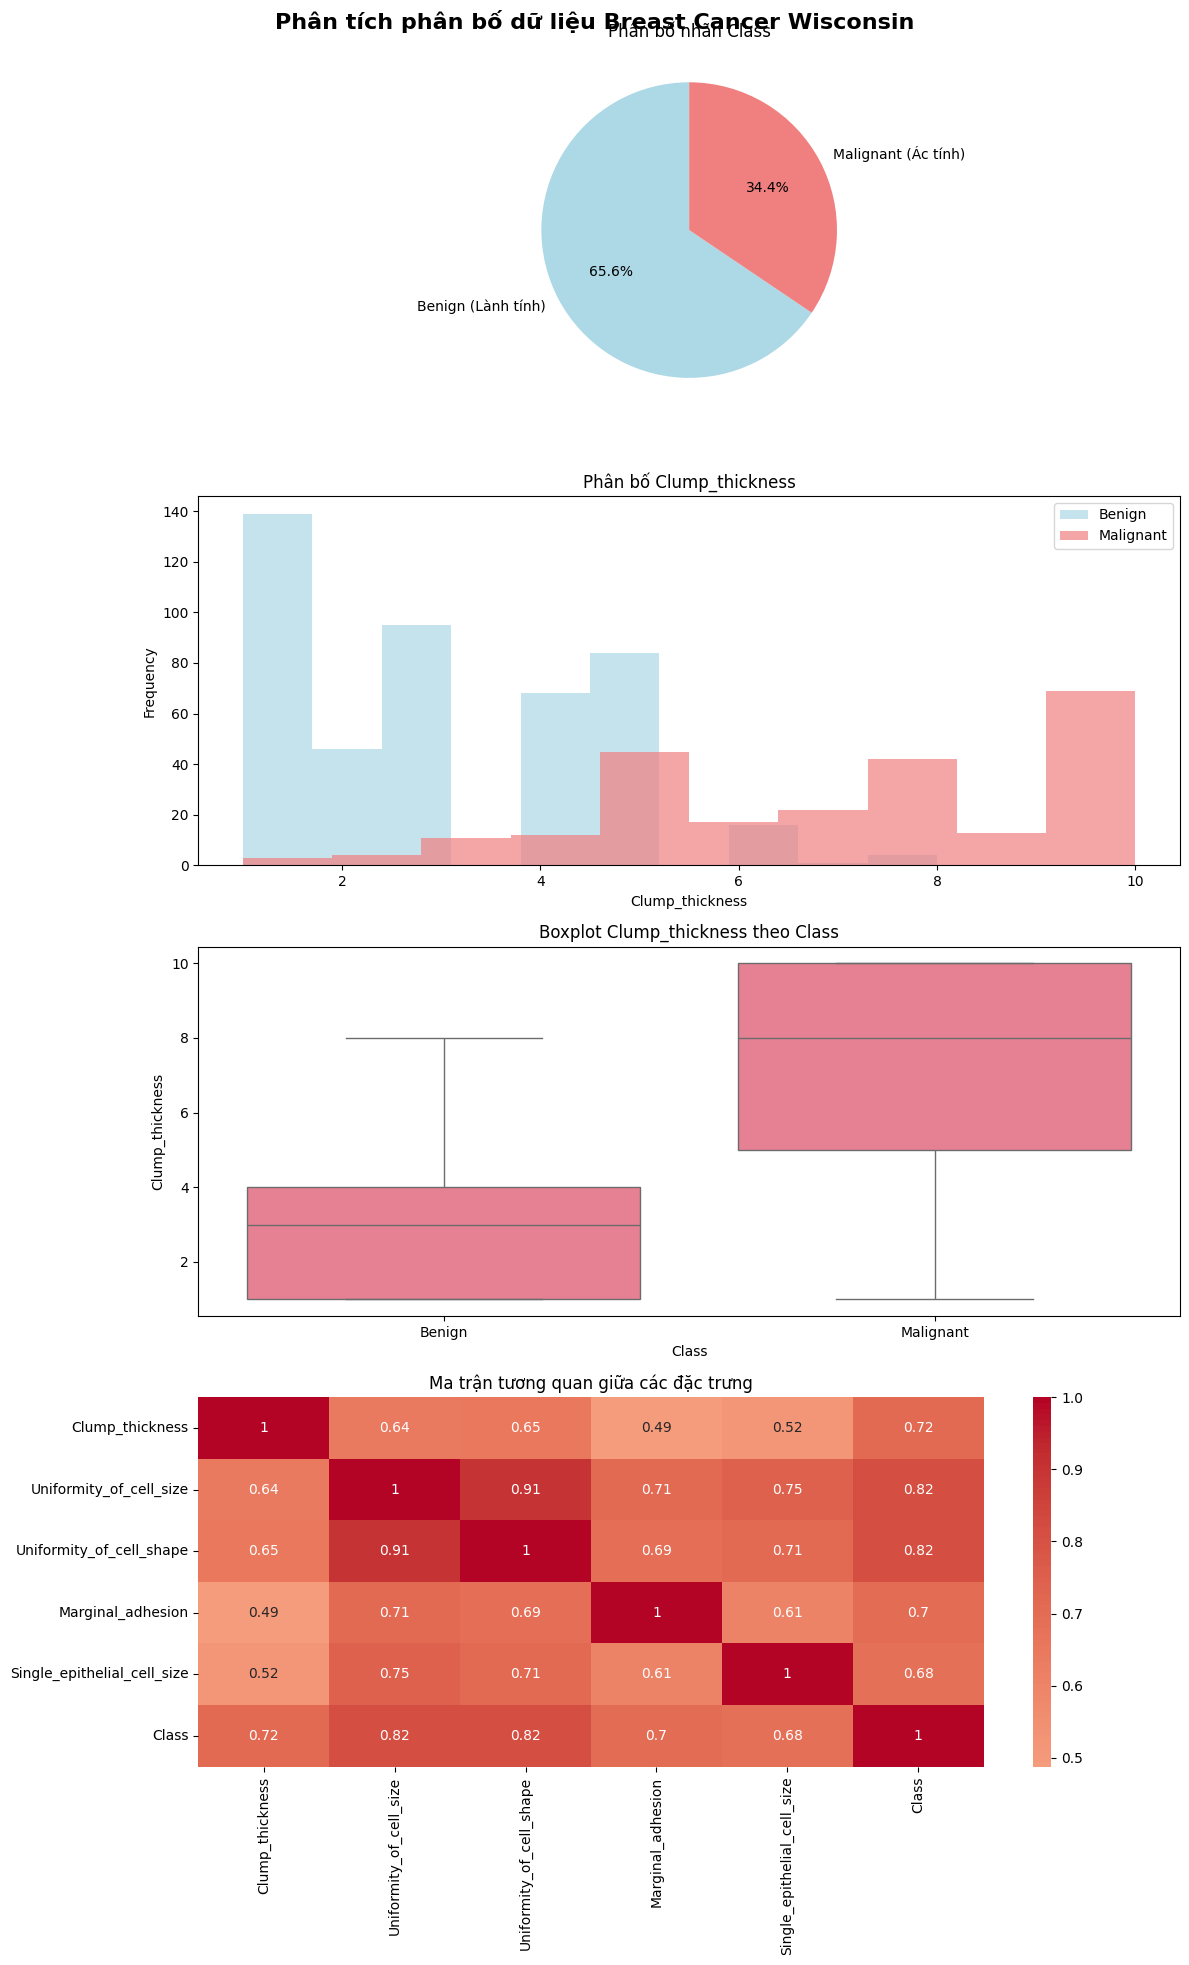

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Thiết lập style cho biểu đồ
plt.style.use('default')
sns.set_palette("husl")

# Tạo figure với 4 subplot theo cột dọc
fig, axes = plt.subplots(4, 1, figsize=(12, 20))
fig.suptitle('Phân tích phân bố dữ liệu Breast Cancer Wisconsin', fontsize=16, fontweight='bold')

# 1. Phân bố nhãn Class
axes[0].pie(data['Class'].value_counts(), labels=['Benign (Lành tính)', 'Malignant (Ác tính)'], 
            autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightcoral'])
axes[0].set_title('Phân bố nhãn Class')

# 2. Histogram của Clump_thickness
axes[1].hist(data[data['Class']==0]['Clump_thickness'], alpha=0.7, label='Benign', bins=10, color='lightblue')
axes[1].hist(data[data['Class']==1]['Clump_thickness'], alpha=0.7, label='Malignant', bins=10, color='lightcoral')
axes[1].set_title('Phân bố Clump_thickness')
axes[1].set_xlabel('Clump_thickness')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# 3. Boxplot để so sánh phân bố giữa 2 nhãn
sns.boxplot(x='Class', y='Clump_thickness', data=data, ax=axes[2])
axes[2].set_title('Boxplot Clump_thickness theo Class')
axes[2].set_xticklabels(['Benign', 'Malignant'])

# 4. Correlation heatmap của một số đặc trưng
features_corr = ['Clump_thickness', 'Uniformity_of_cell_size', 'Uniformity_of_cell_shape', 
                 'Marginal_adhesion', 'Single_epithelial_cell_size', 'Class']
corr_matrix = data[features_corr].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[3])
axes[3].set_title('Ma trận tương quan giữa các đặc trưng')

plt.tight_layout()
plt.show()

## Phân chia tập dữ liệu

In [30]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

In [31]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X, y, test_size = 0.2, stratify=y, random_state = 42)

## Chuẩn hóa dữ liệu

In [32]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Lựa chọn đặc trưng

/tmp/ipykernel_124/1429822825.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances[sorted_indices], y=sorted_features , palette="viridis")


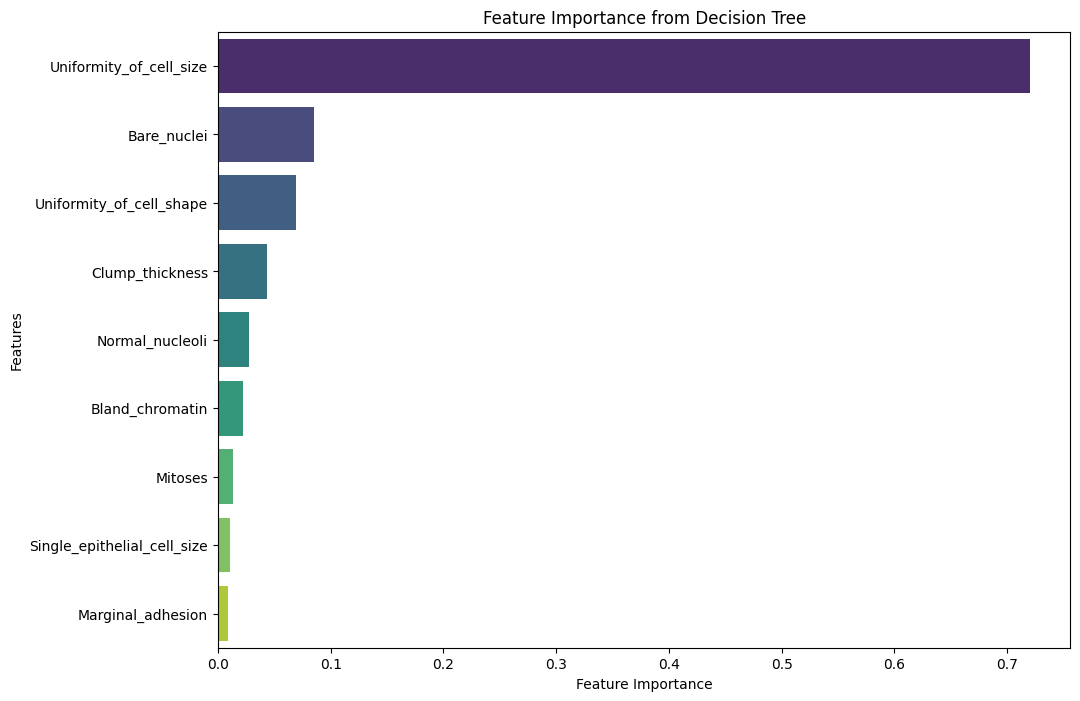

In [33]:
import pandas as pd

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(criterion='gini', random_state=42)
clf.fit(X_train_scaled_df , y_train)

feature_importances = clf.feature_importances_
sorted_indices = np.argsort(feature_importances)[::-1]
sorted_features = X_train.columns[sorted_indices]

plt.figure(figsize=(11,8))
sns.barplot(x=feature_importances[sorted_indices], y=sorted_features , palette="viridis")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance from Decision Tree")
plt.show()


In [34]:
# Giữ lại toàn bộ đặc trưng
X_train = X_train_scaled_df
X_test = X_test_scaled_df

## Random Forest (Baseline)

In [35]:
## Random Forest (Baseline)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# BẮT ĐẦU MLFLOW RUN
with mlflow.start_run(run_name="rf_baseline"):
    
    rf = Pipeline(steps=[
        ("impute", SimpleImputer(strategy="median")),
        ("rf", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            class_weight="balanced",  
            random_state=42,
            n_jobs=-1
        ))
    ])

    rf.fit(X_train, y_train)

    y_pred  = rf.predict(X_test)
    y_proba = rf.predict_proba(X_test)[:, 1]

    # Tính metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    # LOG PARAMETERS
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("max_depth", None)
    mlflow.log_param("min_samples_split", 2)
    mlflow.log_param("min_samples_leaf", 1)
    mlflow.log_param("class_weight", "balanced")
    
    # LOG METRICS
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("precision", prec)
    mlflow.log_metric("recall", rec)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("auc", auc)
    
    # LOG MODEL
    # mlflow.sklearn.log_model(rf, "random_forest_model")

    print("Random Forest:")
    print("  Acc=%.4f  Prec=%.4f  Rec=%.4f  F1=%.4f  AUC=%.4f" % (acc, prec, rec, f1, auc))

Random Forest:
  Acc=0.9784  Prec=0.9787  Rec=0.9583  F1=0.9684  AUC=0.9947
🏃 View run rf_baseline at: http://mlflow:5000/#/experiments/669272814043531891/runs/7cc9f46181b5498e911fa1caf8be401b
🧪 View experiment at: http://mlflow:5000/#/experiments/669272814043531891


## Cross-Validation (Tập train)

In [36]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


import numpy as np
pos_label = 1 if 1 in np.unique(y_train) else np.max(np.unique(y_train))

prec_scorer = make_scorer(precision_score, zero_division=0, pos_label=pos_label)
rec_scorer  = make_scorer(recall_score,    zero_division=0, pos_label=pos_label)
f1_scorer   = make_scorer(f1_score,        zero_division=0, pos_label=pos_label)

# 5 metrics: AUC, F1, Accuracy, Precision, Recall
auc_cv = cross_val_score(rf, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
f1_cv  = cross_val_score(rf, X_train, y_train, cv=cv, scoring=f1_scorer,   n_jobs=-1)
acc_cv = cross_val_score(rf, X_train, y_train, cv=cv, scoring="accuracy",  n_jobs=-1)
pre_cv = cross_val_score(rf, X_train, y_train, cv=cv, scoring=prec_scorer, n_jobs=-1)
rec_cv = cross_val_score(rf, X_train, y_train, cv=cv, scoring=rec_scorer,  n_jobs=-1)

print(f"[RF Baseline — CV 5-fold]")
print(f"Accuracy : {acc_cv.mean():.4f} ± {acc_cv.std():.4f}")
print(f"Precision: {pre_cv.mean():.4f} ± {pre_cv.std():.4f}")
print(f"Recall   : {rec_cv.mean():.4f} ± {rec_cv.std():.4f}")
print(f"F1       : {f1_cv.mean():.4f} ± {f1_cv.std():.4f}")
print(f"AUC      : {auc_cv.mean():.4f} ± {auc_cv.std():.4f}")

[RF Baseline — CV 5-fold]
Accuracy : 0.9638 ± 0.0100
Precision: 0.9353 ± 0.0301
Recall   : 0.9632 ± 0.0316
F1       : 0.9482 ± 0.0139
AUC      : 0.9904 ± 0.0050


## Hyperparameter tuning

In [37]:
## Hyperparameter tuning
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    "rf__n_estimators": [200, 400, 600],
    "rf__max_depth": [None, 8, 12, 16],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4],
    "rf__max_features": ["sqrt", "log2", 0.5],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# BẮT ĐẦU MLFLOW RUN CHO GRID SEARCH
with mlflow.start_run(run_name="rf_tuning"):
    
    grid = GridSearchCV(
        rf, 
        param_grid, 
        scoring="f1", 
        cv=cv, 
        n_jobs=-1, 
        verbose=1,
        refit=True
    )

    grid.fit(X_train, y_train)

    # LOG BEST PARAMS
    mlflow.log_params(grid.best_params_)
    mlflow.log_metric("best_cv_f1", grid.best_score_)

    print("Best params (RF):", grid.best_params_)
    print("Best CV (F1)    :", grid.best_score_)

    best_rf = grid.best_estimator_
    y_pred_b  = best_rf.predict(X_test)
    y_proba_b = best_rf.predict_proba(X_test)[:, 1]

    # Tính metrics trên test
    acc = accuracy_score(y_test, y_pred_b)
    prec = precision_score(y_test, y_pred_b, zero_division=0)
    rec = recall_score(y_test, y_pred_b, zero_division=0)
    f1 = f1_score(y_test, y_pred_b, zero_division=0)
    auc = roc_auc_score(y_test, y_proba_b)

    # LOG TEST METRICS
    mlflow.log_metric("test_accuracy", acc)
    mlflow.log_metric("test_precision", prec)
    mlflow.log_metric("test_recall", rec)
    mlflow.log_metric("test_f1", f1)
    mlflow.log_metric("test_auc", auc)
    
    # LOG BEST MODEL
    # mlflow.sklearn.log_model(best_rf, "best_rf_model")

    print("[RF Tuned - Test]")
    print("  Acc=%.4f  Prec=%.4f  Rec=%.4f  F1=%.4f  AUC=%.4f" % (acc, prec, rec, f1, auc))

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best params (RF): {'rf__max_depth': None, 'rf__max_features': 0.5, 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 10, 'rf__n_estimators': 400}
Best CV (F1)    : 0.9545915646563994
[RF Tuned - Test]
  Acc=0.9784  Prec=0.9592  Rec=0.9792  F1=0.9691  AUC=0.9945
🏃 View run rf_grid_search at: http://mlflow:5000/#/experiments/669272814043531891/runs/aa8ab217ac454c1ebfa5b471a01a2e3e
🧪 View experiment at: http://mlflow:5000/#/experiments/669272814043531891


## Bảng tổng hợp kết quả giữa Baseline và sau khi Tuning

In [38]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def pack_metrics(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_true, y_proba)
    }

df_metrics = pd.DataFrame(
    [pack_metrics(y_test, y_pred, y_proba),
     pack_metrics(y_test, y_pred_b, y_proba_b)],
    index=["RF_Baseline", "RF_Tuned"]
)
df_metrics

,Accuracy,Precision,Recall,F1,AUC
RF_Baseline,0.978417,0.978723,0.958333,0.968421,0.994734
RF_Tuned,0.978417,0.959184,0.979167,0.969072,0.994505


## Đánh giá trực quan: Confusion Matrix, ROC & PR

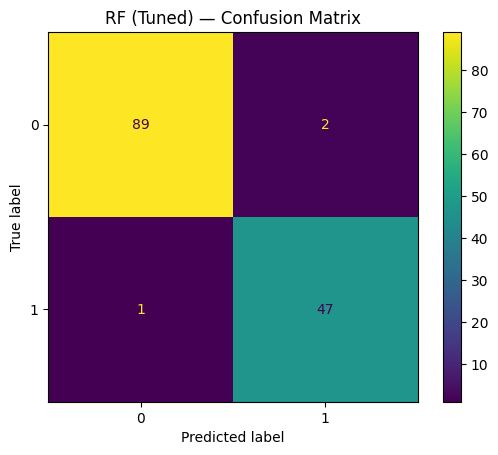

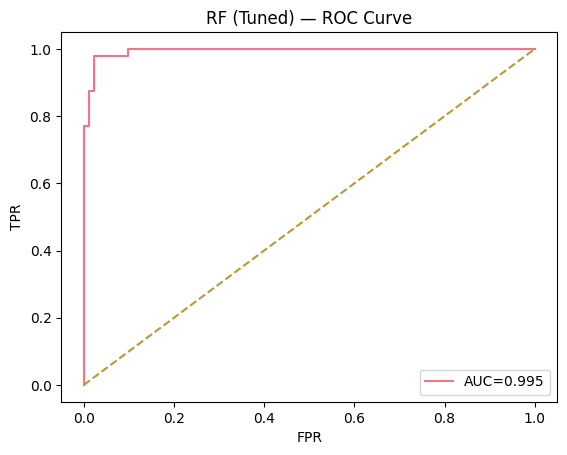

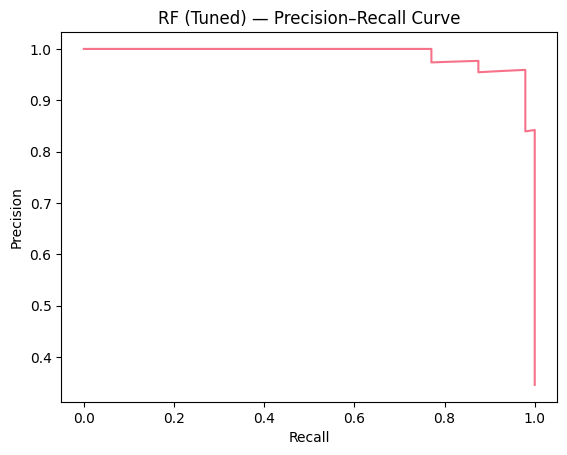

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, precision_recall_curve

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_b)
plt.title("RF (Tuned) — Confusion Matrix"); plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba_b)
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test, y_proba_b):.3f}")
plt.plot([0,1],[0,1],'--'); plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("RF (Tuned) — ROC Curve"); plt.legend(); plt.show()

prec, rec, _ = precision_recall_curve(y_test, y_proba_b)
plt.plot(rec, prec); plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("RF (Tuned) — Precision–Recall Curve"); plt.show()

## Gradient Boosting (Baseline)

In [40]:
## Gradient Boosting (Baseline)
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

SEED = 42

if 'w_train' not in globals():
    n_pos = int((y_train == 1).sum())
    n_neg = int((y_train == 0).sum())
    imb_ratio = n_neg / max(1, n_pos)
    w_train = np.where(y_train == 1, imb_ratio, 1.0)

# BẮT ĐẦU MLFLOW RUN CHO GB BASELINE
with mlflow.start_run(run_name="gb_baseline"):
    
    gb_base = Pipeline(steps=[
        ("impute", SimpleImputer(strategy="median")),
        ("gb", GradientBoostingClassifier(
            loss="log_loss",
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.9,
            random_state=SEED
        ))
    ])

    gb_base.fit(X_train, y_train, gb__sample_weight=w_train)

    y_proba_gb_base = gb_base.predict_proba(X_test)[:, 1]
    y_pred_gb_base  = (y_proba_gb_base >= 0.5).astype(int)

    # Tính metrics
    acc = accuracy_score(y_test, y_pred_gb_base)
    prec = precision_score(y_test, y_pred_gb_base, zero_division=0)
    rec = recall_score(y_test, y_pred_gb_base, zero_division=0)
    f1 = f1_score(y_test, y_pred_gb_base, zero_division=0)
    auc = roc_auc_score(y_test, y_proba_gb_base)

    # LOG PARAMETERS
    mlflow.log_param("model_type", "GradientBoosting")
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", 3)
    mlflow.log_param("subsample", 0.9)
    
    # LOG METRICS
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("precision", prec)
    mlflow.log_metric("recall", rec)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("auc", auc)
    
    # LOG MODEL
    # mlflow.sklearn.log_model(gb_base, "gradient_boosting_model")

    print("[GB Baseline - Test]")
    print("  Acc=%.4f  Prec=%.4f  Rec=%.4f  F1=%.4f  AUC=%.4f" % (acc, prec, rec, f1, auc))

[GB Baseline - Test]
  Acc=0.9568  Prec=0.9565  Rec=0.9167  F1=0.9362  AUC=0.9947
🏃 View run gb_baseline at: http://mlflow:5000/#/experiments/669272814043531891/runs/1cff0aad59504bab807b6d930ea6deb8
🧪 View experiment at: http://mlflow:5000/#/experiments/669272814043531891


## Độ ổn định bằng Cross-Validation (Tập train)

In [41]:
# 6.9 Gradient Boosting — Cross-Validation (5 metrics, manual CV, FIX .iloc)
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score

SEED = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# helper: lấy theo vị trí, hỗ trợ cả pandas và numpy
def take_pos(arr, idx):
    return arr.iloc[idx] if hasattr(arr, "iloc") else arr[idx]

# đảm bảo w_train thẳng hàng với y_train
if 'w_train' not in globals():
    n_pos = int((y_train == 1).sum())
    n_neg = int((y_train == 0).sum())
    imb_ratio = n_neg / max(1, n_pos)
    # tạo numpy array để index theo vị trí cho chắc
    w_train = np.where(np.asarray(y_train) == 1, imb_ratio, 1.0)

auc_scores, f1_scores = [], []
acc_scores, pre_scores, rec_scores = [], [], []

for tr_idx, va_idx in cv.split(X_train, y_train):
    X_tr = take_pos(X_train, tr_idx)
    X_va = take_pos(X_train, va_idx)
    y_tr = take_pos(y_train, tr_idx)
    y_va = take_pos(y_train, va_idx)

    # w_train là numpy -> index trực tiếp theo vị trí
    w_tr = w_train[tr_idx]

    est = clone(gb_base)                         # mỗi fold một mô hình mới
    est.fit(X_tr, y_tr, gb__sample_weight=w_tr)  # truyền sample_weight cho step 'gb'

    proba = est.predict_proba(X_va)[:, 1]
    pred  = (proba >= 0.5).astype(int)

    auc_scores.append(roc_auc_score(y_va, proba))
    f1_scores.append(f1_score(y_va, pred, zero_division=0))
    acc_scores.append(accuracy_score(y_va, pred))
    pre_scores.append(precision_score(y_va, pred, zero_division=0))
    rec_scores.append(recall_score(y_va, pred, zero_division=0))

def mean_std(a):
    a = np.asarray(a, dtype=float)
    return a.mean(), a.std()

auc_m, auc_s = mean_std(auc_scores)
f1_m,  f1_s  = mean_std(f1_scores)
acc_m, acc_s = mean_std(acc_scores)
pre_m, pre_s = mean_std(pre_scores)
rec_m, rec_s = mean_std(rec_scores)

print("[GB Baseline — CV 5-fold]")
print(f"AUC      : {auc_m:.4f} ± {auc_s:.4f}")
print(f"F1       : {f1_m:.4f} ± {f1_s:.4f}")
print(f"Accuracy : {acc_m:.4f} ± {acc_s:.4f}")
print(f"Precision: {pre_m:.4f} ± {pre_s:.4f}")
print(f"Recall   : {rec_m:.4f} ± {rec_s:.4f}")


[GB Baseline — CV 5-fold]
AUC      : 0.9902 ± 0.0045
F1       : 0.9400 ± 0.0224
Accuracy : 0.9583 ± 0.0159
Precision: 0.9334 ± 0.0296
Recall   : 0.9474 ± 0.0288


## Hyperparameter tuning

In [ ]:
## Hyperparameter tuning cho GB
from sklearn.model_selection import GridSearchCV

gb_tune = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("gb", GradientBoostingClassifier(
        loss="log_loss",
        random_state=SEED
    ))
])

param_grid_gb = {
    "gb__n_estimators":    [200, 400, 600],
    "gb__learning_rate":   [0.03, 0.05, 0.1],
    "gb__max_depth":       [2, 3, 4],
    "gb__subsample":       [0.7, 0.85, 1.0],
    "gb__min_samples_split":[2, 5, 10],
    "gb__min_samples_leaf":[1, 2, 4],
    "gb__max_features":    ["sqrt", "log2", None],
}

# BẮT ĐẦU MLFLOW RUN CHO GB TUNING
with mlflow.start_run(run_name="gb_tuning"):
    
    grid_gb = GridSearchCV(
        estimator=gb_tune,
        param_grid=param_grid_gb,
        scoring="f1",          
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    grid_gb.fit(X_train, y_train, **{"gb__sample_weight": w_train})

    # LOG BEST PARAMS
    mlflow.log_params(grid_gb.best_params_)
    mlflow.log_metric("best_cv_f1", grid_gb.best_score_)

    print("Best params (GB):", grid_gb.best_params_)
    print("Best CV (F1)   :", grid_gb.best_score_)

    gb_best = grid_gb.best_estimator_
    y_proba_gb_best = gb_best.predict_proba(X_test)[:, 1]
    y_pred_gb_best  = (y_proba_gb_best >= 0.5).astype(int)

    # Tính metrics trên test
    acc = accuracy_score(y_test, y_pred_gb_best)
    prec = precision_score(y_test, y_pred_gb_best, zero_division=0)
    rec = recall_score(y_test, y_pred_gb_best, zero_division=0)
    f1 = f1_score(y_test, y_pred_gb_best, zero_division=0)
    auc = roc_auc_score(y_test, y_proba_gb_best)

    # LOG TEST METRICS
    mlflow.log_metric("test_accuracy", acc)
    mlflow.log_metric("test_precision", prec)
    mlflow.log_metric("test_recall", rec)
    mlflow.log_metric("test_f1", f1)
    mlflow.log_metric("test_auc", auc)
    
    # LOG BEST MODEL
    # mlflow.sklearn.log_model(gb_best, "best_gb_model")

    print("[GB Tuned - Test]")
    print("  Acc=%.4f  Prec=%.4f  Rec=%.4f  F1=%.4f  AUC=%.4f" % (acc, prec, rec, f1, auc))

Fitting 5 folds for each of 2187 candidates, totalling 10935 fits


## Bảng tổng hợp kết quả giữa Baseline và sau khi Tuned

In [ ]:
import pandas as pd

def pack_metrics(y_true, y_pred, y_proba):
    return {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred, zero_division=0),
        "F1":        f1_score(y_true, y_pred, zero_division=0),
        "AUC":       roc_auc_score(y_true, y_proba),
    }

df_gb_compare = pd.DataFrame(
    [
        pack_metrics(y_test, y_pred_gb_base, y_proba_gb_base),
        pack_metrics(y_test, y_pred_gb_best, y_proba_gb_best),
    ],
    index=["GB_Baseline", "GB_Tuned"]
)
print("\n[GB — So sánh Baseline vs Tuned]")
display(df_gb_compare)

## Đánh giá trực quan: Confusion Matrix, ROC & PR

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, precision_recall_curve

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gb_best)
plt.title("GB (Tuned) — Confusion Matrix"); plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba_gb_best)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test, y_proba_gb_best):.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("GB (Tuned) — ROC Curve"); plt.legend(); plt.show()

prec, rec, _ = precision_recall_curve(y_test, y_proba_gb_best)
plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("GB (Tuned) — Precision–Recall Curve"); plt.show()